In [15]:
from colav_automaton import ColavAutomaton
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import numpy as np
import matplotlib.pyplot as plt
from hybrid_automaton_evaluation.figure_generator import continuous_states_over_time_fig, auxiliary_states_over_time_fig, automaton_states_over_time, transitions_times_over_time_fig

In [ ]:
ha: Automaton = ColavAutomaton(
    heading_tolerance=0.2, 
    k_theta=1.0, 
    constant_velocity=2.0, 
    acceptance_radius=5, 
    los_distance_threshold=100, 
    longitudinal_offset_distance=50.0, 
    lateral_offset_distance=50.0
)
print (ha)

Hybrid Automaton Definition:
	name: COLAV Automaton
	id: 1
	initial_mode: Cruise
	modes: [Cruise, Transition_to_LOS, Fallback, Waypoint_Reached]
	transitions:
		Cruise --[e1]--> Transition_to_LOS
		Cruise --[e2]--> Transition_to_LOS
		Cruise --[e3]--> Fallback
		Cruise --[e4]--> Waypoint_Reached
		Transition_to_LOS --[e5]--> Cruise
		Transition_to_LOS --[e6]--> Cruise
		Waypoint_Reached --[e7]--> Cruise
	guards:
		e1: [heading_not_within_tolerance_guard]
		e2: [los_clear_to_waypoint_guard]
		e3: [unsafe_conditions_guard]
		e4: [waypoint_reached_guard]
		e5: [heading_within_tolerance_guard]
		e6: [unsafe_conditions_guard]
		e7: [virtual_waypoints_guard]
	resets:
		e1: <none>
		e2: generate_new_virtual_waypoint
		e3: <none>
		e4: <none>
		e5: <none>
		e6: <none>
		e7: pop_waypoint
	invariants:
		Cruise: [virtual_waypoints_guard]
		Transition_to_LOS: [virtual_waypoints_guard]
		Fallback: [virtual_waypoints_guard]
		Waypoint_Reached: [virtual_waypoints_guard]
	continous_dynamics:
		Cruise 

In [17]:
print (repr(ha))

stateDiagram-v2
    direction LR
    [*] --> Cruise
    Cruise --> Transition_to_LOS: e1
    Cruise --> Transition_to_LOS: e2
    Cruise --> Fallback: e3
    Cruise --> Waypoint_Reached: e4
    Transition_to_LOS --> Cruise: e5
    Transition_to_LOS --> Cruise: e6
    Waypoint_Reached --> Cruise: e7
    note right of Waypoint_Reached: invariant = is_goal_waypoint_invariant


In [18]:
x0 = np.array([-200.0, -200.0, 0.0, 0.0, 0.0], dtype=float)
aux_t0 = {
    "waypoints": [np.array([200, 200]), np.array([-200, 200]), np.array([-100, 80]), np.array([200, -200])],
    "unsafe_region": [
        np.array([20, 20]), 
        np.array([-50, -50]),
        np.array([50, -50]),
        np.array([50, 100]),
        np.array([-50, 100])
    ]
}

In [19]:
ha_runner: AutomatonRunner = AutomatonRunner(ha, sampling_rate=0.001)
await ha_runner.run(
    x0=x0,
    aux_x0=aux_t0,
    duration=15.0,
    real_time_mode=False,
    integrate=True,
    dt=0.1,
    collect_control=False
)

activating automaton 'COLAV Automaton'...
automaton 'COLAV Automaton' evaluation loop worker starting.
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
waypoint_reached
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
waypoint_reached
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LO

{'continuous_states': [[0.1, array([-200. , -200. ,    0. ,    0.2,    0. ])],
  [0.2,
   array([-1.99980000e+02, -2.00000000e+02,  7.85398163e-02,  3.80000000e-01,
           0.00000000e+00])],
  [0.30000000000000004,
   array([-1.99942117e+02, -1.99997019e+02,  1.49228151e-01,  5.42000000e-01,
           0.00000000e+00])],
  [0.4,
   array([-199.88851951, -199.98896037,    0.21285202,    0.6878    ,
             0.        ])],
  [0.5,
   array([-199.82129171, -199.97443071,    0.27011919,    0.81902   ,
             0.        ])],
  [0.6,
   array([-199.74235955, -199.95257546,    0.32166623,    0.937118  ,
             0.        ])],
  [0.7,
   array([-199.65345423, -199.92294869,    0.36806571,    1.0434062 ,
             0.        ])],
  [0.7999999999999999,
   array([-199.55610182, -199.88540575,    0.40983266,    1.13906558,
             0.        ])],
  [0.8999999999999999,
   array([-199.45162815, -199.84001901,    0.4474304 ,    1.22515902,
             0.        ])],
  [0.99

In [20]:
results = ha_runner.get_results()

Number of waypoints: 4
Waypoint 1: [200 200]
Waypoint 2: [-200  200]
Waypoint 3: [-100   80]
Waypoint 4: [ 200 -200]


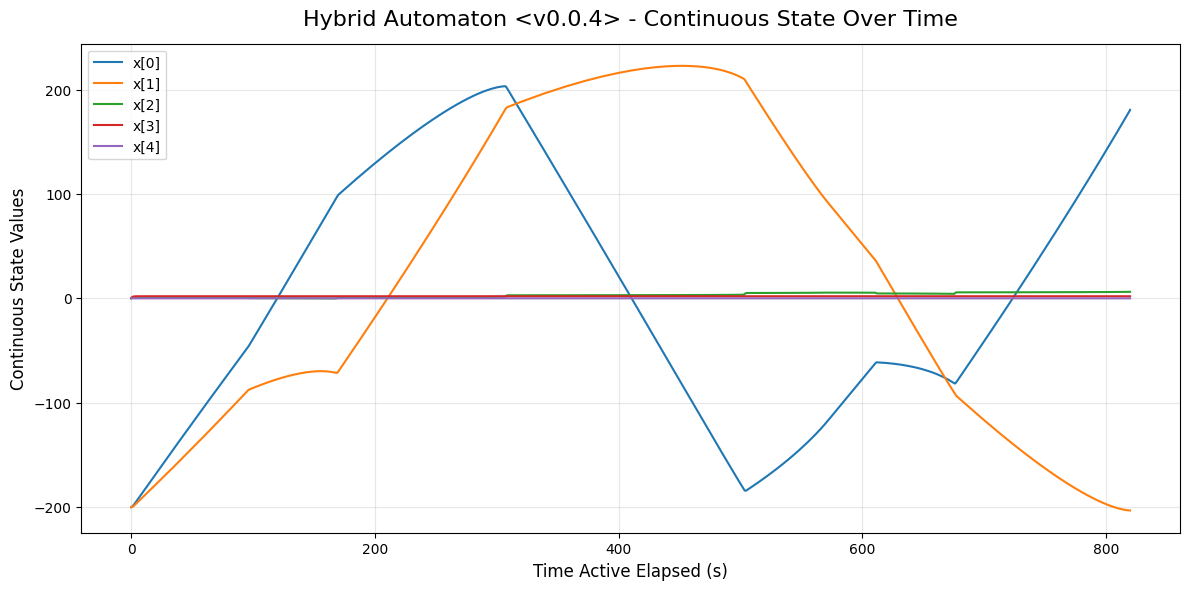

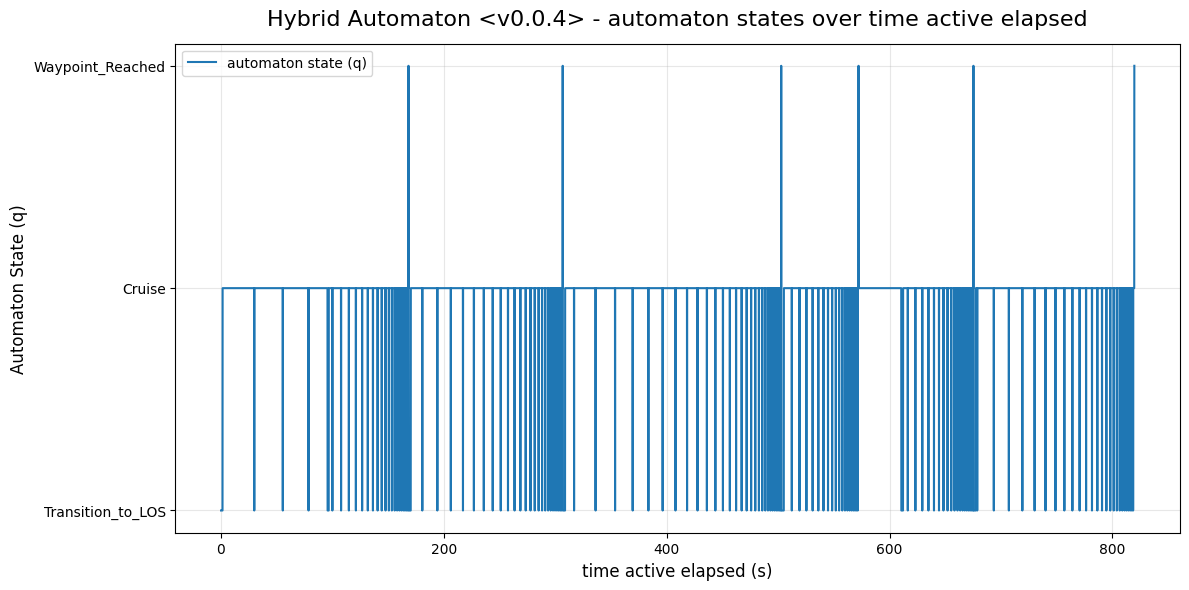

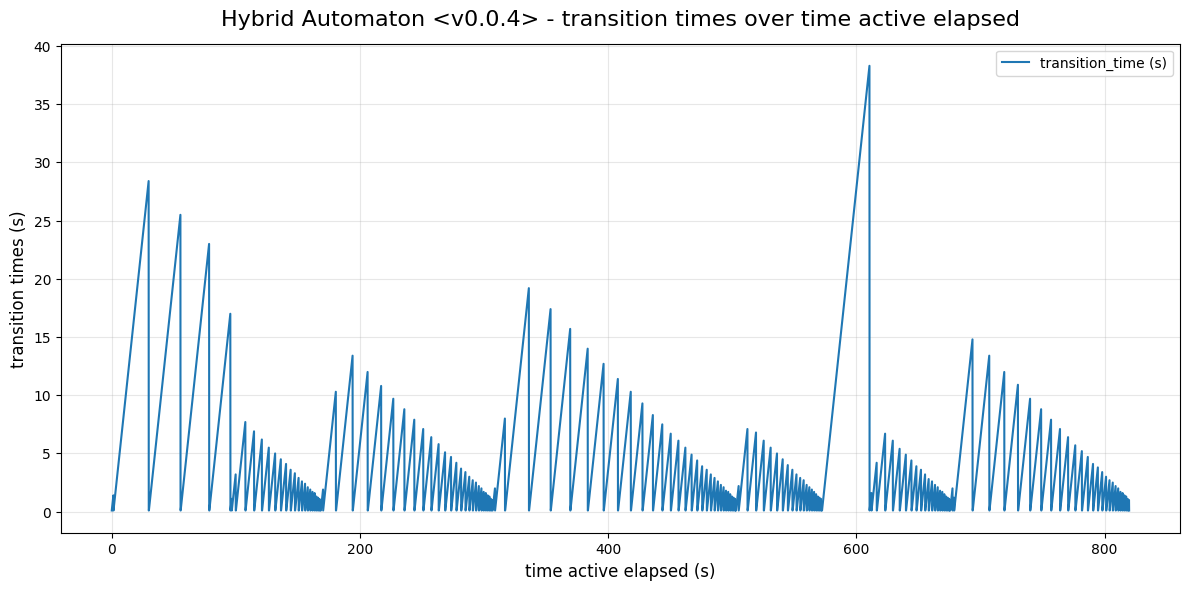

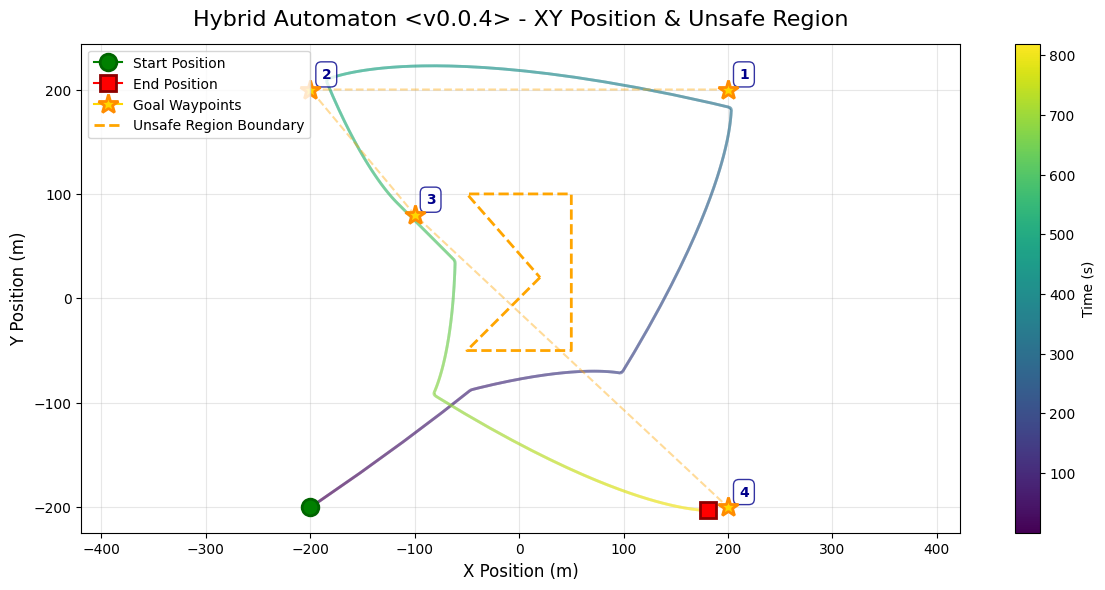

In [21]:
fig1 = continuous_states_over_time_fig(results['continuous_states'])
# fig2 = auxiliary_states_over_time_fig(results['auxiliary_states'])
fig3 = automaton_states_over_time(results['automaton_states'])
fig4 = transitions_times_over_time_fig(results['transition_times'])    

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

x = results['continuous_states']
aux_x_vertices = aux_t0['unsafe_region']
aux_x0_waypoints = [np.array([200, 200]), np.array([-200, 200]), np.array([-100, 80]), np.array([200, -200])]

def plot_xy_position_over_time(x, aux_t0, aux_x_vertices, waypoints=None):
    timestamps = np.array([continuous_state[0] for continuous_state in x])
    continuous_state_values = np.array([continuous_state[1] for continuous_state in x])
    
    # Extract x and y positions (indices 0 and 1 of the state vector)
    x_positions = continuous_state_values[:, 0]
    y_positions = continuous_state_values[:, 1]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # --- Vehicle trajectory with time-based coloring ---
    # Create line segments
    points = np.array([x_positions, y_positions]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create a LineCollection with colors based on timestamps
    norm = Normalize(vmin=timestamps.min(), vmax=timestamps.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm, linewidth=2)
    lc.set_array(timestamps[:-1])  # Color each segment by its start time
    
    line = ax.add_collection(lc)
    
    # Add colorbar
    cbar = fig.colorbar(line, ax=ax, label='Time (s)')
    
    # --- Mark starting position ---
    ax.plot(x_positions[0], y_positions[0], 
            marker='o', markersize=12, color='green', 
            markeredgecolor='darkgreen', markeredgewidth=2,
            label='Start Position', zorder=5)
    
    # --- Mark ending position ---
    ax.plot(x_positions[-1], y_positions[-1], 
            marker='s', markersize=12, color='red', 
            markeredgecolor='darkred', markeredgewidth=2,
            label='End Position', zorder=5)
    
    # --- Plot waypoints ---
    if waypoints is not None and len(waypoints) > 0:
        # Plot each waypoint individually
        for i, wp in enumerate(waypoints):
            if i == 0:
                # First waypoint gets the label for legend
                ax.plot(wp[0], wp[1],
                       marker='*', markersize=15, color='gold',
                       markeredgecolor='darkorange', markeredgewidth=2,
                       label='Goal Waypoints', zorder=4)
            else:
                ax.plot(wp[0], wp[1],
                       marker='*', markersize=15, color='gold',
                       markeredgecolor='darkorange', markeredgewidth=2,
                       zorder=4)
            
            # Number each waypoint
            ax.annotate(f'{i+1}', xy=(wp[0], wp[1]), 
                       xytext=(8, 8), textcoords='offset points',
                       fontsize=10, color='darkblue', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                                edgecolor='darkblue', alpha=0.8))
        
        # Draw connecting lines between waypoints
        waypoints_array = np.array([wp for wp in waypoints])
        ax.plot(waypoints_array[:, 0], waypoints_array[:, 1],
                linestyle='--', linewidth=1.5, alpha=0.4, color='orange',
                zorder=3)
    
    # --- Unsafe region (polygon exterior) ---
    verts = np.array(aux_x_vertices)
    closed_verts = np.vstack([verts, verts[0]])   # Close polygon
    unsafe_line = ax.plot(
        closed_verts[:, 0],
        closed_verts[:, 1],
        linewidth=2,
        linestyle='--',
        color='orange',
        label='Unsafe Region Boundary'
    )[0]
    
    # Formatting
    ax.set_title('Hybrid Automaton <v0.0.4> - XY Position & Unsafe Region', fontsize=16, y=1.02)
    ax.set_xlabel("X Position (m)", fontsize=12)
    ax.set_ylabel("Y Position (m)", fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    
    # Auto-scale to fit all data
    ax.autoscale()
    
    fig.tight_layout()
    return fig

# Debug: print waypoints to see what we have
print(f"Number of waypoints: {len(aux_x0_waypoints)}")
for i, wp in enumerate(aux_x0_waypoints):
    print(f"Waypoint {i+1}: {wp}")

# Call with waypoints
fig5 = plot_xy_position_over_time(x, aux_t0, aux_x_vertices, waypoints=aux_x0_waypoints)
plt.show()